In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("HousingData.csv")

# Display first few rows
print("Dataset Preview:")
print(df.head())

# Check basic info
print("\nDataset Info:")
print(df.info())

# Summary statistics
print("\nDataset Summary:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())







Dataset Preview:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4  

Load & Explore the Dataset


2. Handle Missing Values

In [3]:
# Option 1: Drop missing values (if the dataset is small)
df = df.dropna()

# Option 2: Fill missing values (if dropping is not preferred)
# df.fillna(df.median(), inplace=True)  # Replace NaNs with median

print("\nMissing Values After Handling:")
print(df.isnull().sum())  # Should now be 0



Missing Values After Handling:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [4]:
#3. Feature Selection & Target Variable

# Define target variable
target = "MEDV"

# Define feature variables (excluding target)
features = [col for col in df.columns if col != target]

print("Features:", features)
print("Target Variable:", target)

Features: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
Target Variable: MEDV


In [5]:
#4. Normalize Numerical Features
#We use Min-Max Scaling (0 to 1 range) for better model performance.

#python

from sklearn.preprocessing import MinMaxScaler

# Apply Min-Max Scaling
scaler = MinMaxScaler()
df[features] = scaler.fit_transform(df[features])

print("\nFirst Few Rows After Normalization:")
print(df.head())


First Few Rows After Normalization:
       CRIM    ZN     INDUS  CHAS       NOX        RM       AGE       DIS  \
0  0.000000  0.18  0.067815   0.0  0.309129  0.577505  0.641607  0.269203   
1  0.000236  0.00  0.242302   0.0  0.165975  0.547998  0.782698  0.348962   
2  0.000236  0.00  0.242302   0.0  0.165975  0.694386  0.599382  0.348962   
3  0.000293  0.00  0.063050   0.0  0.143154  0.658555  0.441813  0.448545   
5  0.000264  0.00  0.063050   0.0  0.143154  0.549722  0.574665  0.448545   

        RAD       TAX   PTRATIO         B     LSTAT  MEDV  
0  0.000000  0.208015  0.287234  1.000000  0.089680  24.0  
1  0.043478  0.104962  0.553191  1.000000  0.204470  21.6  
2  0.043478  0.104962  0.553191  0.989678  0.063466  34.7  
3  0.086957  0.066794  0.648936  0.994243  0.033389  33.4  
5  0.086957  0.066794  0.648936  0.992950  0.096026  28.7  


In [8]:
#5. Encode Categorical Features (if any)
#Check if there are categorical features:


# Identify categorical columns
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("\nCategorical Columns:", categorical_cols)
#If categorical features exist, apply One-Hot Encoding:

if categorical_cols:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
    print("\nDataset After Encoding:")
    print(df.head())
    


Categorical Columns: []


C:\Users\PMYLS\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


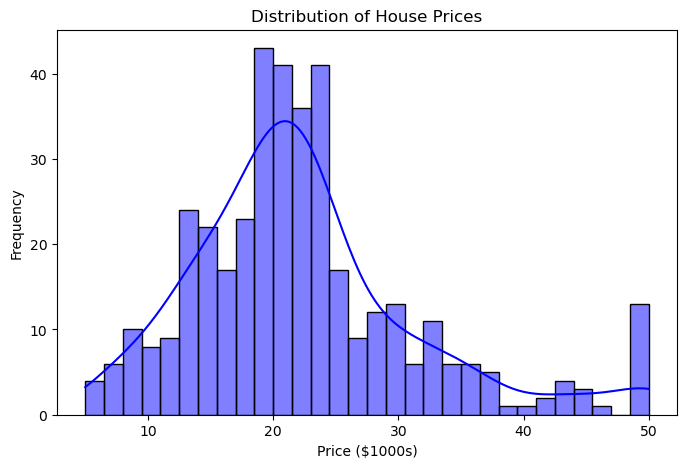

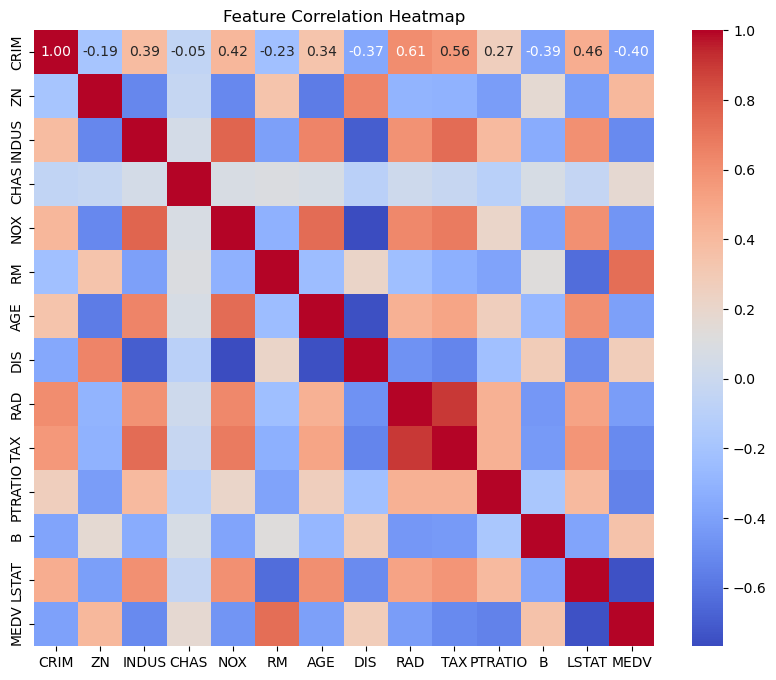

In [9]:
#6. Visualizing Data

# Histogram of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df[target], bins=30, kde=True, color="blue")
plt.title("Distribution of House Prices")
plt.xlabel("Price ($1000s)")
plt.ylabel("Frequency")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


Next Steps: Model Implementation
Now that the dataset is preprocessed, the next step is:
Linear Regression from Scratch

Step 1: Implement Linear Regression from Scratch
We’ll implement Linear Regression using Gradient Descent step by step:
Define the cost function (Mean Squared Error - MSE)
 Implement Gradient Descent for optimization
 Train the model
 Make predictions
 Evaluate performance using RMSE and R²



1. Define Helper Functions
We need functions for:

Computing cost (MSE)

Updating weights using Gradient Descent

Making predictions

Evaluating model performance

In [10]:
import numpy as np

class LinearRegressionScratch:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None

    def compute_cost(self, X, y):
        """Calculate Mean Squared Error (MSE)"""
        n = len(y)
        y_pred = np.dot(X, self.weights) + self.bias
        mse = (1 / (2 * n)) * np.sum((y_pred - y) ** 2)
        return mse

    def fit(self, X, y):
        """Train the model using Gradient Descent"""
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)  # Initialize weights
        self.bias = 0

        for epoch in range(self.epochs):
            # Compute predictions
            y_pred = np.dot(X, self.weights) + self.bias

            # Compute gradients
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            # Update weights
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Print cost every 100 iterations
            if epoch % 100 == 0:
                cost = self.compute_cost(X, y)
                print(f"Epoch {epoch}: Cost = {cost}")

    def predict(self, X):
        """Make predictions on new data"""
        return np.dot(X, self.weights) + self.bias

    def evaluate(self, X, y):
        """Calculate RMSE and R²"""
        y_pred = self.predict(X)
        rmse = np.sqrt(np.mean((y_pred - y) ** 2))
        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_residual = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_residual / ss_total)
        return rmse, r2


In [11]:
#2. Prepare Data for Training
#python

from sklearn.model_selection import train_test_split

# Convert DataFrame to numpy arrays
X = df[features].values  # Features
y = df[target].values  # Target variable

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}, Testing samples: {X_test.shape[0]}")


Training samples: 315, Testing samples: 79


In [12]:
#3. Train & Evaluate Linear Regression Model
#python

# Initialize model
lr_model = LinearRegressionScratch(learning_rate=0.01, epochs=1000)

# Train the model
lr_model.fit(X_train, y_train)

# Evaluate on test data
rmse, r2 = lr_model.evaluate(X_test, y_test)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test R² Score: {r2:.4f}")

Epoch 0: Cost = 266.4018471658262
Epoch 100: Cost = 43.85508884149795
Epoch 200: Cost = 32.96171003923094
Epoch 300: Cost = 27.157409531547387
Epoch 400: Cost = 23.851181723173497
Epoch 500: Cost = 21.80954971288943
Epoch 600: Cost = 20.424390266335653
Epoch 700: Cost = 19.394162509634324
Epoch 800: Cost = 18.56783307285123
Epoch 900: Cost = 17.868428027594
Test RMSE: 7.3332
Test R² Score: 0.3624


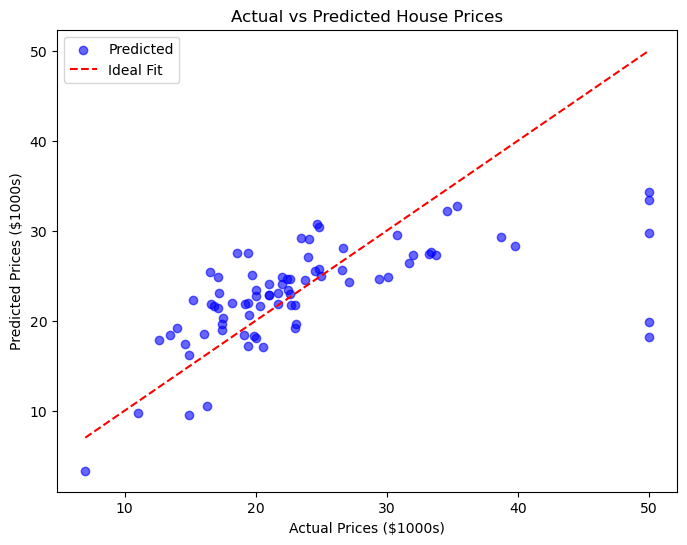

In [13]:
#4. Visualizing Model Predictions
#python


import matplotlib.pyplot as plt

# Predictions on test data
y_pred = lr_model.predict(X_test)

# Scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label="Predicted")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='dashed', label="Ideal Fit")
plt.xlabel("Actual Prices ($1000s)")
plt.ylabel("Predicted Prices ($1000s)")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()

Step 2: Implement Random Forest from Scratch
We will implement Random Forest using the following steps:
 Define Decision Tree using a recursive split
 Implement Bootstrap Aggregation (Bagging) for multiple trees
 Train the Random Forest model
 Make predictions
 Evaluate performance using RMSE and R²

1. Implement Decision Tree from Scratch
We will create a Decision Tree Regressor that uses the following:

Mean Squared Error (MSE) for finding the best split

Recursive splitting until a stopping condition is met

Leaf nodes store the average target value of the samples

In [14]:
import numpy as np

class DecisionTree:
    def __init__(self, min_samples_split=10, max_depth=10):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.tree = None

    def mse(self, y):
        """Compute Mean Squared Error"""
        return np.var(y) * len(y) if len(y) > 0 else 0

    def best_split(self, X, y):
        """Find the best split point using MSE"""
        n_samples, n_features = X.shape
        if n_samples <= self.min_samples_split:
            return None, None

        best_mse = float("inf")
        best_feature, best_threshold = None, None

        for feature in range(n_features):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = X[:, feature] > threshold
                left_mse = self.mse(y[left_mask])
                right_mse = self.mse(y[right_mask])
                total_mse = (left_mse + right_mse) / n_samples

                if total_mse < best_mse:
                    best_mse = total_mse
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def build_tree(self, X, y, depth=0):
        """Recursively build the tree"""
        n_samples, n_features = X.shape
        if depth >= self.max_depth or n_samples < self.min_samples_split:
            return np.mean(y)

        feature, threshold = self.best_split(X, y)
        if feature is None:
            return np.mean(y)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        left_subtree = self.build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self.build_tree(X[right_mask], y[right_mask], depth + 1)

        return {"feature": feature, "threshold": threshold, "left": left_subtree, "right": right_subtree}

    def fit(self, X, y):
        """Train the decision tree"""
        self.tree = self.build_tree(X, y)

    def predict_sample(self, sample, tree):
        """Predict a single sample"""
        if isinstance(tree, dict):
            feature, threshold = tree["feature"], tree["threshold"]
            if sample[feature] <= threshold:
                return self.predict_sample(sample, tree["left"])
            else:
                return self.predict_sample(sample, tree["right"])
        return tree

    def predict(self, X):
        """Predict multiple samples"""
        return np.array([self.predict_sample(sample, self.tree) for sample in X])


2. Implement Random Forest Regressor
Now, we create the Random Forest by:

Creating multiple Decision Trees

Using Bootstrap Sampling

Aggregating predictions using Averaging


In [15]:
import random

class RandomForestScratch:
    def __init__(self, n_trees=10, max_depth=10, min_samples_split=10, sample_ratio=0.8):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.sample_ratio = sample_ratio
        self.trees = []

    def bootstrap_sample(self, X, y):
        """Generate a bootstrap sample"""
        n_samples = int(self.sample_ratio * len(y))
        indices = np.random.choice(len(y), n_samples, replace=True)
        return X[indices], y[indices]

    def fit(self, X, y):
        """Train multiple decision trees"""
        self.trees = []
        for _ in range(self.n_trees):
            X_sample, y_sample = self.bootstrap_sample(X, y)
            tree = DecisionTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        """Make predictions by averaging results from all trees"""
        predictions = np.array([tree.predict(X) for tree in self.trees])
        return np.mean(predictions, axis=0)

    def evaluate(self, X, y):
        """Compute RMSE and R² score"""
        y_pred = self.predict(X)
        rmse = np.sqrt(np.mean((y_pred - y) ** 2))
        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_residual = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_residual / ss_total)
        return rmse, r2


In [16]:
#3. Train & Evaluate the Random Forest Model
#python

# Initialize Random Forest
rf_model = RandomForestScratch(n_trees=10, max_depth=10, min_samples_split=10)

# Train the model
rf_model.fit(X_train, y_train)

# Evaluate the model
rmse, r2 = rf_model.evaluate(X_test, y_test)
print(f"Random Forest Test RMSE: {rmse:.4f}")
print(f"Random Forest Test R² Score: {r2:.4f}")

Random Forest Test RMSE: 5.4672
Random Forest Test R² Score: 0.6456


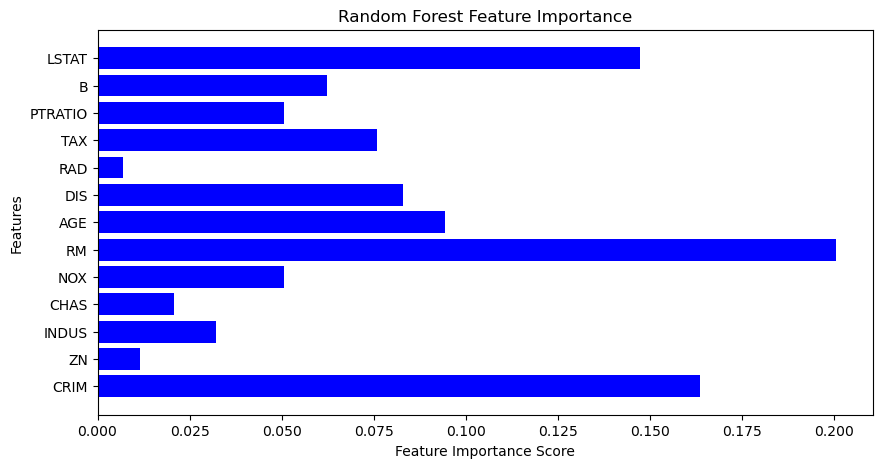

In [17]:
#4. Visualizing Feature Importance

import matplotlib.pyplot as plt

def feature_importance(model, X):
    """Compute feature importance based on how often each feature is used for splitting"""
    importance = np.zeros(X.shape[1])
    for tree in model.trees:
        def extract_features(tree):
            if isinstance(tree, dict):
                importance[tree["feature"]] += 1
                extract_features(tree["left"])
                extract_features(tree["right"])

        extract_features(tree.tree)

    return importance / np.sum(importance)  # Normalize

# Compute feature importance
importance = feature_importance(rf_model, X_train)

# Plot feature importance
plt.figure(figsize=(10, 5))
plt.barh(features, importance, color="blue")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.show()


Step 3: Implement XGBoost from Scratch
XGBoost is a gradient boosting algorithm that improves upon traditional decision trees and random forests.
We will implement XGBoost by:
 Computing gradients & hessians
 Building trees to reduce the loss function
 Aggregating weak learners into a strong model




1. Implement XGBoost Tree (Single Weak Learner)
Each tree in XGBoost is trained using Gradient Descent, where:

We compute the gradient (first derivative of the loss function)

We compute the hessian (second derivative for adaptive learning rate)

We find the best split by minimizing loss reduction

In [18]:
import numpy as np

class XGBoostTree:
    def __init__(self, max_depth=5, min_samples_split=10, lambda_reg=1):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.lambda_reg = lambda_reg
        self.tree = None

    def gradient(self, y_true, y_pred):
        """Compute gradient (negative first derivative of loss)"""
        return y_pred - y_true  

    def hessian(self, y_true, y_pred):
        """Compute hessian (second derivative of loss)"""
        return np.ones_like(y_true)  

    def loss_reduction(self, g_left, h_left, g_right, h_right):
        """Compute loss reduction for a split"""
        return 0.5 * ((g_left**2 / (h_left + self.lambda_reg)) +
                      (g_right**2 / (h_right + self.lambda_reg)))

    def best_split(self, X, gradients, hessians):
        """Find the best split by minimizing loss reduction"""
        best_feature, best_threshold = None, None
        best_gain = -np.inf

        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                right_mask = X[:, feature] > threshold

                g_left, h_left = np.sum(gradients[left_mask]), np.sum(hessians[left_mask])
                g_right, h_right = np.sum(gradients[right_mask]), np.sum(hessians[right_mask])

                gain = self.loss_reduction(g_left, h_left, g_right, h_right)
                if gain > best_gain:
                    best_gain = gain
                    best_feature, best_threshold = feature, threshold

        return best_feature, best_threshold

    def build_tree(self, X, gradients, hessians, depth=0):
        """Recursively build XGBoost tree"""
        if depth >= self.max_depth or len(gradients) < self.min_samples_split:
            return -np.sum(gradients) / (np.sum(hessians) + self.lambda_reg)

        feature, threshold = self.best_split(X, gradients, hessians)
        if feature is None:
            return -np.sum(gradients) / (np.sum(hessians) + self.lambda_reg)

        left_mask = X[:, feature] <= threshold
        right_mask = X[:, feature] > threshold

        return {
            "feature": feature,
            "threshold": threshold,
            "left": self.build_tree(X[left_mask], gradients[left_mask], hessians[left_mask], depth + 1),
            "right": self.build_tree(X[right_mask], gradients[right_mask], hessians[right_mask], depth + 1),
        }

    def fit(self, X, y, y_pred):
        """Train an XGBoost tree using gradients"""
        gradients = self.gradient(y, y_pred)
        hessians = self.hessian(y, y_pred)
        self.tree = self.build_tree(X, gradients, hessians)

    def predict_sample(self, sample, tree):
        """Predict a single sample"""
        if isinstance(tree, dict):
            feature, threshold = tree["feature"], tree["threshold"]
            if sample[feature] <= threshold:
                return self.predict_sample(sample, tree["left"])
            else:
                return self.predict_sample(sample, tree["right"])
        return tree

    def predict(self, X):
        """Predict multiple samples"""
        return np.array([self.predict_sample(sample, self.tree) for sample in X])


2. Implement XGBoost Model (Gradient Boosting Framework)
The XGBoost Regressor:

Starts with initial predictions (usually the mean of y)

Iteratively adds trees to correct the errors

Uses learning rate to control how much each tree contributes


In [19]:
class XGBoostScratch:
    def __init__(self, n_trees=50, max_depth=5, min_samples_split=10, learning_rate=0.1):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.learning_rate = learning_rate
        self.trees = []
        self.initial_prediction = None

    def fit(self, X, y):
        """Train multiple boosting trees"""
        self.initial_prediction = np.mean(y)
        y_pred = np.full_like(y, self.initial_prediction)

        for _ in range(self.n_trees):
            tree = XGBoostTree(max_depth=self.max_depth, min_samples_split=self.min_samples_split)
            tree.fit(X, y, y_pred)
            y_pred += self.learning_rate * tree.predict(X)
            self.trees.append(tree)

    def predict(self, X):
        """Make predictions using the sum of weak learners"""
        y_pred = np.full(X.shape[0], self.initial_prediction)
        for tree in self.trees:
            y_pred += self.learning_rate * tree.predict(X)
        return y_pred

    def evaluate(self, X, y):
        """Compute RMSE and R² score"""
        y_pred = self.predict(X)
        rmse = np.sqrt(np.mean((y_pred - y) ** 2))
        ss_total = np.sum((y - np.mean(y)) ** 2)
        ss_residual = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_residual / ss_total)
        return rmse, r2


In [20]:
#3. Train & Evaluate the XGBoost Model
#python

# Initialize XGBoost
xgb_model = XGBoostScratch(n_trees=50, max_depth=5, learning_rate=0.1)

# Train the model
xgb_model.fit(X_train, y_train)

# Evaluate the model
rmse, r2 = xgb_model.evaluate(X_test, y_test)
print(f"XGBoost Test RMSE: {rmse:.4f}")
print(f"XGBoost Test R² Score: {r2:.4f}")


XGBoost Test RMSE: 5.3639
XGBoost Test R² Score: 0.6589


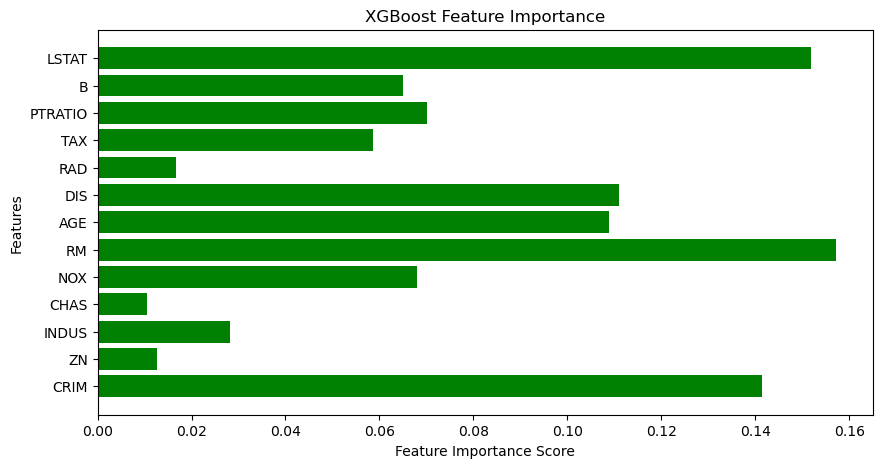

In [22]:
def feature_importance_xgb(model, X):
    """Compute feature importance based on how often each feature is used for splitting"""
    importance = np.zeros(X.shape[1])

    def extract_features(tree):
        if isinstance(tree, dict):  # Ensure tree is a dictionary
            feature = tree.get("feature")
            if feature is not None:  # Only count valid splits
                importance[feature] += 1
                extract_features(tree["left"])
                extract_features(tree["right"])

    # Loop through all trees in the model and extract feature importance
    for tree in model.trees:
        extract_features(tree.tree)  # Corrected reference

    return importance / np.sum(importance)  # Normalize

# Compute feature importance
importance = feature_importance_xgb(xgb_model, X_train)

# Plot feature importance
plt.figure(figsize=(10, 5))
plt.barh(features, importance, color="green")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("XGBoost Feature Importance")
plt.show()
